# Milestone 1 — EDA, Text Processing & Baseline Similarity Metrics
**Smart MCQ Solver Challenge** · Introduction to DL and GenAI Project (BSDA2001P)

**Name:** Vihaan Bhambhani  **Roll No:** 24f1002825  **Term:** T2-2026

---
This notebook covers the Milestone 1 deliverables: exploratory data analysis of the
answer distribution, text normalization and vocabulary construction, TF-IDF + cosine
similarity baselines, the MAP@3 metric, and two baseline submissions
(majority-class and a TF-IDF lexical pipeline).

**Headline finding:** purely lexical similarity scores *below random* on this dataset —
the distractor options are written to share more surface vocabulary with the prompt than
the correct answer does. This motivates the contextual / retrieval-based models in later
milestones.

In [1]:
import os, re, string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity

# Portable data path: Kaggle competition mount, local ./data, or current dir
DATA_DIR = "/kaggle/input/competitions/smart-mcq-solver-challenge"
for alt in ["/kaggle/input/smart-mcq-solver-challenge", "data", "."]:
    if not os.path.exists(os.path.join(DATA_DIR, "train.csv")):
        DATA_DIR = alt
train = pd.read_csv(f"{DATA_DIR}/train.csv")
LABELS = ["A", "B", "C", "D", "E"]
print(f"train.csv shape: {train.shape}")
train.head(2)

train.csv shape: (2000, 8)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A


## Q1 — Answer frequency distribution
Count of each correct label (A–E); report the sum of the most and least frequent.

answer
B    490
C    459
A    369
D    358
E    324

Most frequent : B = 490
Least frequent: E = 324
Q1 ANSWER (sum): 814


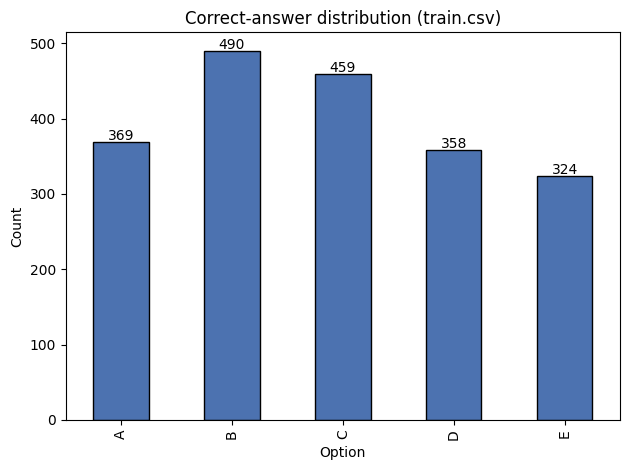

In [2]:
counts = train["answer"].value_counts()
print(counts.to_string())

most_lbl, least_lbl = counts.idxmax(), counts.idxmin()
q1 = int(counts.max() + counts.min())
print(f"\nMost frequent : {most_lbl} = {counts.max()}")
print(f"Least frequent: {least_lbl} = {counts.min()}")
print(f"Q1 ANSWER (sum): {q1}")

ax = counts.reindex(LABELS).plot(kind="bar", color="#4C72B0", edgecolor="black")
ax.set_title("Correct-answer distribution (train.csv)")
ax.set_xlabel("Option"); ax.set_ylabel("Count")
for i, v in enumerate(counts.reindex(LABELS)):
    ax.text(i, v + 3, str(v), ha="center")
plt.tight_layout(); plt.show()

## Q2 — Vocabulary size of the cleaned prompt column
Lowercase each prompt, delete all `string.punctuation` characters, split on whitespace,
and count the unique tokens across the whole column.

In [3]:
def clean_tokens(text):
    text = str(text).lower().translate(str.maketrans("", "", string.punctuation))
    return text.split()

vocab = set()
train["prompt"].apply(lambda p: vocab.update(clean_tokens(p)))
q2 = len(vocab)
print(f"Q2 ANSWER (unique words in cleaned prompt column): {q2}")

Q2 ANSWER (unique words in cleaned prompt column): 859


## Q3 — Stopword filtering on Row ID 1 *(optional question)*
Take the cleaned prompt for `id == 1`, remove sklearn `ENGLISH_STOP_WORDS`, count what remains.

In [4]:
row1 = train.loc[train["id"] == 1].iloc[0]
toks1 = clean_tokens(row1["prompt"])
kept = [w for w in toks1 if w not in ENGLISH_STOP_WORDS]
print(f"Cleaned tokens in Row 1 : {len(toks1)}")
print(f"Q3 ANSWER (after stopword removal): {len(kept)}")
print("Remaining tokens:", kept)

Cleaned tokens in Row 1 : 22
Q3 ANSWER (after stopword removal): 13
Remaining tokens: ['pick', 'best', 'possible', 'answer', 'martin', 'heideggers', 'view', 'relationship', 'time', 'human', 'existence', 'listed', 'options']


## Q4 — TF-IDF vocabulary size
Fit a default `TfidfVectorizer(stop_words='english')` on the combined corpus of all prompts
and all five option columns. Report the number of feature columns.

In [5]:
corpus = list(train["prompt"].astype(str))
for c in LABELS:
    corpus += list(train[c].astype(str))

vectorizer = TfidfVectorizer(stop_words="english")
vectorizer.fit(corpus)
q4 = len(vectorizer.vocabulary_)
print(f"Corpus documents: {len(corpus)}")
print(f"Q4 ANSWER (TF-IDF feature columns): {q4}")

Corpus documents: 12000
Q4 ANSWER (TF-IDF feature columns): 2762


## Q5 — Cosine similarity: prompt vs option A, Row ID 1
Transform both texts with the fitted vectorizer and take the cosine similarity (TF-IDF rows
are L2-normalized, so this is a clean cosine).

In [6]:
p1 = vectorizer.transform([str(row1["prompt"])])
a1 = vectorizer.transform([str(row1["A"])])
q5 = cosine_similarity(p1, a1)[0, 0]
print(f"Q5 ANSWER (cosine prompt vs A, Row 1, 4dp): {q5:.4f}")

Q5 ANSWER (cosine prompt vs A, Row 1, 4dp): 0.2328


## Q6 — Lexical top-1 accuracy
For every row, cosine-similarity the prompt against each option; how often is the
highest-similarity option the correct answer?

In [7]:
P = vectorizer.transform(train["prompt"].astype(str))
OPT = {c: vectorizer.transform(train[c].astype(str)) for c in LABELS}

sims = np.zeros((len(train), 5))
for j, c in enumerate(LABELS):
    sims[:, j] = cosine_similarity(P, OPT[c]).diagonal()

top1 = np.array(LABELS)[sims.argmax(1)]
q6 = (top1 == train["answer"].values).mean()
print(f"Q6 ANSWER (% argmax-cosine == answer): {q6*100:.4f}%")
print(f"(Random guess baseline would be 20%.)")

Q6 ANSWER (% argmax-cosine == answer): 13.7000%
(Random guess baseline would be 20%.)


## MAP@3 metric
$$\text{MAP@3} = \frac{1}{N}\sum_{q} \sum_{k=1}^{3} \frac{[\,\text{pred}_k = \text{truth}\,]}{k}$$
Credit only for the first correct hit: rank 1 → 1.0, rank 2 → 0.5, rank 3 → 0.333, miss → 0.

In [8]:
def map_at_3(truth, preds):
    for i, p in enumerate(preds[:3]):
        if p == truth:
            return 1.0 / (i + 1)
    return 0.0

q7 = map_at_3("C", ["C", "A", "B"])   # correct at rank 1
q8 = map_at_3("B", ["D", "B", "E"])   # correct at rank 2
print(f"Q7 ANSWER (truth C, pred C A B): {q7}")
print(f"Q8 ANSWER (truth B, pred D B E): {q8}")

Q7 ANSWER (truth C, pred C A B): 1.0
Q8 ANSWER (truth B, pred D B E): 0.5


## Q9 — Majority-class baseline
Predict the same static ranking (most → 2nd → 3rd most frequent label) for every row,
and average the MAP@3.

In [9]:
freq_order = counts.index.tolist()       # most -> least frequent
static_pred = freq_order[:3]
print(f"Static prediction: {static_pred}")

q9 = np.mean([map_at_3(a, static_pred) for a in train["answer"]])
print(f"Q9 ANSWER (majority-class MAP@3): {q9:.4f}")

Static prediction: ['B', 'C', 'A']
Q9 ANSWER (majority-class MAP@3): 0.4213


## Q10 — TF-IDF cosine pipeline baseline
Rank each row's options by prompt-cosine, take top 3, average the MAP@3 over the train set.

In [10]:
order = np.argsort(-sims, axis=1)
top3 = [[LABELS[k] for k in row[:3]] for row in order]
q10 = np.mean([map_at_3(a, t) for a, t in zip(train["answer"], top3)])
print(f"Q10 ANSWER (TF-IDF pipeline MAP@3): {q10:.4f}")
print("Note: BELOW the 0.3667 random-guess MAP@3 — distractors are lexically closer")
print("to the prompt than the correct answer, so surface similarity is anti-predictive.")

Q10 ANSWER (TF-IDF pipeline MAP@3): 0.3082
Note: BELOW the 0.3667 random-guess MAP@3 — distractors are lexically closer
to the prompt than the correct answer, so surface similarity is anti-predictive.


## Answer summary

In [11]:
print("Milestone 1 — answers")
print("="*40)
print(f"Q1  sum(most,least)         : {q1}")
print(f"Q2  cleaned prompt vocab    : {q2}")
print(f"Q3  Row1 after stopwords    : {len(kept)}")
print(f"Q4  TF-IDF feature columns  : {q4}")
print(f"Q5  cosine prompt/A row1    : {q5:.4f}")
print(f"Q6  argmax-cosine accuracy  : {q6*100:.4f}%")
print(f"Q7  MAP@3 (C | C A B)       : {q7}")
print(f"Q8  MAP@3 (B | D B E)       : {q8}")
print(f"Q9  majority-class MAP@3    : {q9:.4f}")
print(f"Q10 TF-IDF pipeline MAP@3   : {q10:.4f}")

Milestone 1 — answers
Q1  sum(most,least)         : 814
Q2  cleaned prompt vocab    : 859
Q3  Row1 after stopwords    : 13
Q4  TF-IDF feature columns  : 2762
Q5  cosine prompt/A row1    : 0.2328
Q6  argmax-cosine accuracy  : 13.7000%
Q7  MAP@3 (C | C A B)       : 1.0
Q8  MAP@3 (B | D B E)       : 0.5
Q9  majority-class MAP@3    : 0.4213
Q10 TF-IDF pipeline MAP@3   : 0.3082


## Baseline Kaggle submission (Milestone 1 requirement)
Milestone 1 requires at least one leaderboard submission. We write the majority-class
static prediction for the test set — a valid, reproducible baseline.

In [12]:
test_path = f"{DATA_DIR}/test.csv"
if os.path.exists(test_path):
    test = pd.read_csv(test_path)
    pred_str = " ".join(static_pred)
    sub = pd.DataFrame({"ID": test["id"], "Prediction": [pred_str] * len(test)})
    sub.to_csv("submission_baseline.csv", index=False)
    print(f"Wrote submission_baseline.csv ({len(sub)} rows), every row = '{pred_str}'")
    print(sub.head())
else:
    print("test.csv not found in DATA_DIR; skipping submission file.")

Wrote submission_baseline.csv (500 rows), every row = 'B C A'
   ID Prediction
0   1      B C A
1   2      B C A
2   3      B C A
3   4      B C A
4   5      B C A
